In [118]:
import torch

from src.vision_transformer.common.patch_embedding import PatchEmbedding
from src.vision_transformer.common.swin_transformer_encoder_layer import SwinTransformerBlock

input_image = torch.rand(1, 3, 512, 512)

patch_embedding_module = PatchEmbedding(
    in_channels=3,
    embed_dim=768,
    patch_size=16,
    image_size=512,
)
print("Patched resolution: ", patch_embedding_module.resolution)
patch_embedding = patch_embedding_module(input_image)
print("Patch Embedding Shape", patch_embedding.shape)
B, P, E = patch_embedding.shape

window_size = patch_embedding_module.H // 4
shift_size = window_size // 2

swin_transformer_layer = SwinTransformerBlock(
    dim=E,
    num_heads=2,
    window_size=[window_size, window_size],
    shift_size=[shift_size, shift_size],
)
patch_embedding, attn_scores = swin_transformer_layer(patch_embedding, return_attention_weights=True)
print("Patch Embedding Shape", patch_embedding.shape)
print("Attention Scores Shape", attn_scores.shape)


Patched resolution:  (32, 32)
Patch Embedding Shape torch.Size([1, 1024, 768])
Patch Embedding Shape torch.Size([1, 1024, 768])
Attention Scores Shape torch.Size([16, 2, 64, 64])


In [119]:
from src.vision_transformer.common.transformer_encoder_layer import TransformerEncoderLayer

transformer_encoder_layer = TransformerEncoderLayer(
    d_model=E,
    nhead=2,
    dim_feedforward=E * 2,
    batch_first=True,
)
patch_embedding_2, attn_scores_2 = transformer_encoder_layer(patch_embedding, return_attention_weights=True)
print("Patch Embedding Shape", patch_embedding_2.shape)
print("Attention Scores Shape", attn_scores_2.shape)


Patch Embedding Shape torch.Size([1, 1024, 768])
Attention Scores Shape torch.Size([1, 2, 1024, 1024])


In [120]:
import matplotlib.pyplot as _plt
import numpy as _np
import torch.nn as _nn
from PIL import Image as _Image

w_featmap, h_featmap = patch_embedding_module.resolution
patch_size = 16
use_max_pooling = False
attentions = attn_scores

W, H, _, E = attentions.shape
if use_max_pooling:
    attentions = attentions.max(dim=2).values
else:
    attentions = attentions[:, :, 0, :]
attentions = attentions.permute(1, 0, 2).reshape(H, W * E)
attentions = attentions.reshape(H, w_featmap, h_featmap)
attentions = (
    _nn.functional.interpolate(
        attentions.unsqueeze(0), scale_factor=patch_size, mode="nearest"
    )[0]
    .detach()
    .cpu()
    .numpy()
)

In [121]:
attentions.shape

(2, 512, 512)

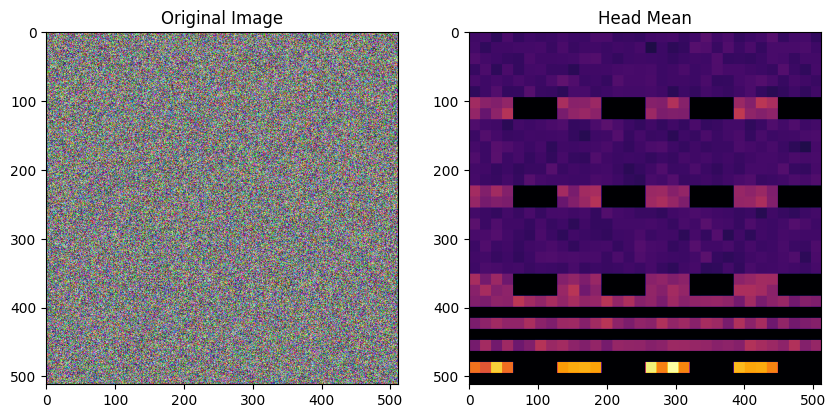

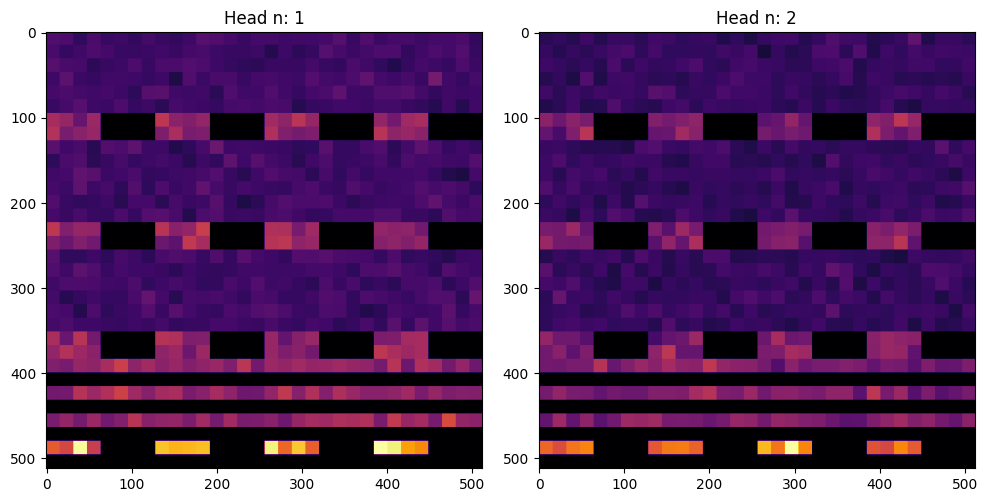

In [122]:
img = torch.rand(3, 512, 512)

img = img.detach().cpu().permute(1, 2, 0).numpy()
img = (img * 255).astype(_np.uint8)
img = _Image.fromarray(img)

n_heads = attentions.shape[0]

_plt.figure(figsize=(10, 10))
text = ["Original Image", "Head Mean"]
for i, fig in enumerate([img, _np.mean(attentions, 0)]):
    _plt.subplot(1, 2, i + 1)
    _plt.imshow(fig, cmap="inferno")
    _plt.title(text[i])
_plt.show()

_plt.figure(figsize=(10, 10))
for i in range(n_heads):
    _plt.subplot(n_heads // 2, 2, i + 1)
    _plt.imshow(attentions[i], cmap="inferno")
    _plt.title(f"Head n: {i + 1}")
_plt.tight_layout()
_plt.show()

In [123]:
attentions = attn_scores_2

H = attentions.shape[1]  # number of head
# keep only the output patch attention
use_max_pooling = False
if use_max_pooling:
    attentions = attentions[0].max(dim=1).values
else:
    attentions = attentions[0, :, 0, :].reshape(H, -1)

attentions = attentions.reshape(H, w_featmap, h_featmap)
attentions = (
    _nn.functional.interpolate(
        attentions.unsqueeze(0), scale_factor=patch_size, mode="nearest"
    )[0]
    .detach()
    .cpu()
    .numpy()
)
print(attentions.shape)

(2, 512, 512)


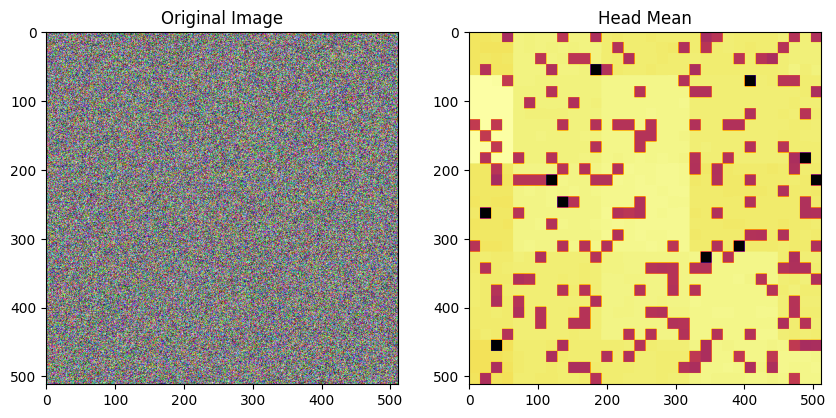

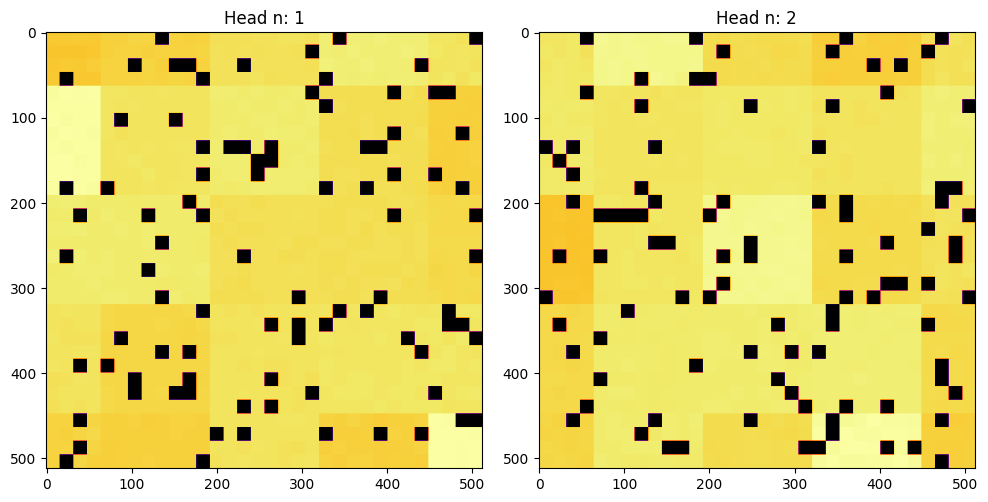

In [124]:
img = torch.rand(3, 512, 512)

img = img.detach().cpu().permute(1, 2, 0).numpy()
img = (img * 255).astype(_np.uint8)
img = _Image.fromarray(img)

n_heads = attentions.shape[0]

_plt.figure(figsize=(10, 10))
text = ["Original Image", "Head Mean"]
for i, fig in enumerate([img, _np.mean(attentions, 0)]):
    _plt.subplot(1, 2, i + 1)
    _plt.imshow(fig, cmap="inferno")
    _plt.title(text[i])
_plt.show()

_plt.figure(figsize=(10, 10))
for i in range(n_heads):
    _plt.subplot(n_heads // 2, 2, i + 1)
    _plt.imshow(attentions[i], cmap="inferno")
    _plt.title(f"Head n: {i + 1}")
_plt.tight_layout()
_plt.show()